## Import Visualization and Evaluation Libraries

In [10]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns


## Load Trained Models from Disk

In [12]:
model_names = [
    "logistic_regression_ultra",
    "decision_tree_ultra",
    "random_forest_ultra",
    "extra_trees_ultra",
    "gradient_boosting_ultra",
    "adaboost_ultra",
    "bagging_ultra",
    "knn_ultra",
    "naive_bayes_ultra"
]

models = {
    name.replace("_ultra", "").replace("_", " ").title():
    joblib.load(f"../models/{name}.pkl")
    for name in model_names
}

models.keys()


dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'Adaboost', 'Bagging', 'Knn', 'Naive Bayes'])

## Calculate Core Classification Metrics

In [13]:
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    }

results_df = pd.DataFrame(results).T.sort_values("F1-score", ascending=False)
results_df


,Accuracy,Precision,Recall,F1-score
Random Forest,0.901639,0.892857,0.892857,0.892857
Gradient Boosting,0.885246,0.838710,0.928571,0.881356
Logistic Regression,0.885246,0.862069,0.892857,0.877193
Naive Bayes,0.885246,0.862069,0.892857,0.877193
Decision Tree,0.868852,0.857143,0.857143,0.857143
Adaboost,0.868852,0.857143,0.857143,0.857143
Knn,0.868852,0.884615,0.821429,0.851852
Extra Trees,0.852459,0.827586,0.857143,0.842105
Bagging,0.836066,0.781250,0.892857,0.833333


## Import Scikit-Learn Metrics

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)


## Visualize Confusion Matrices

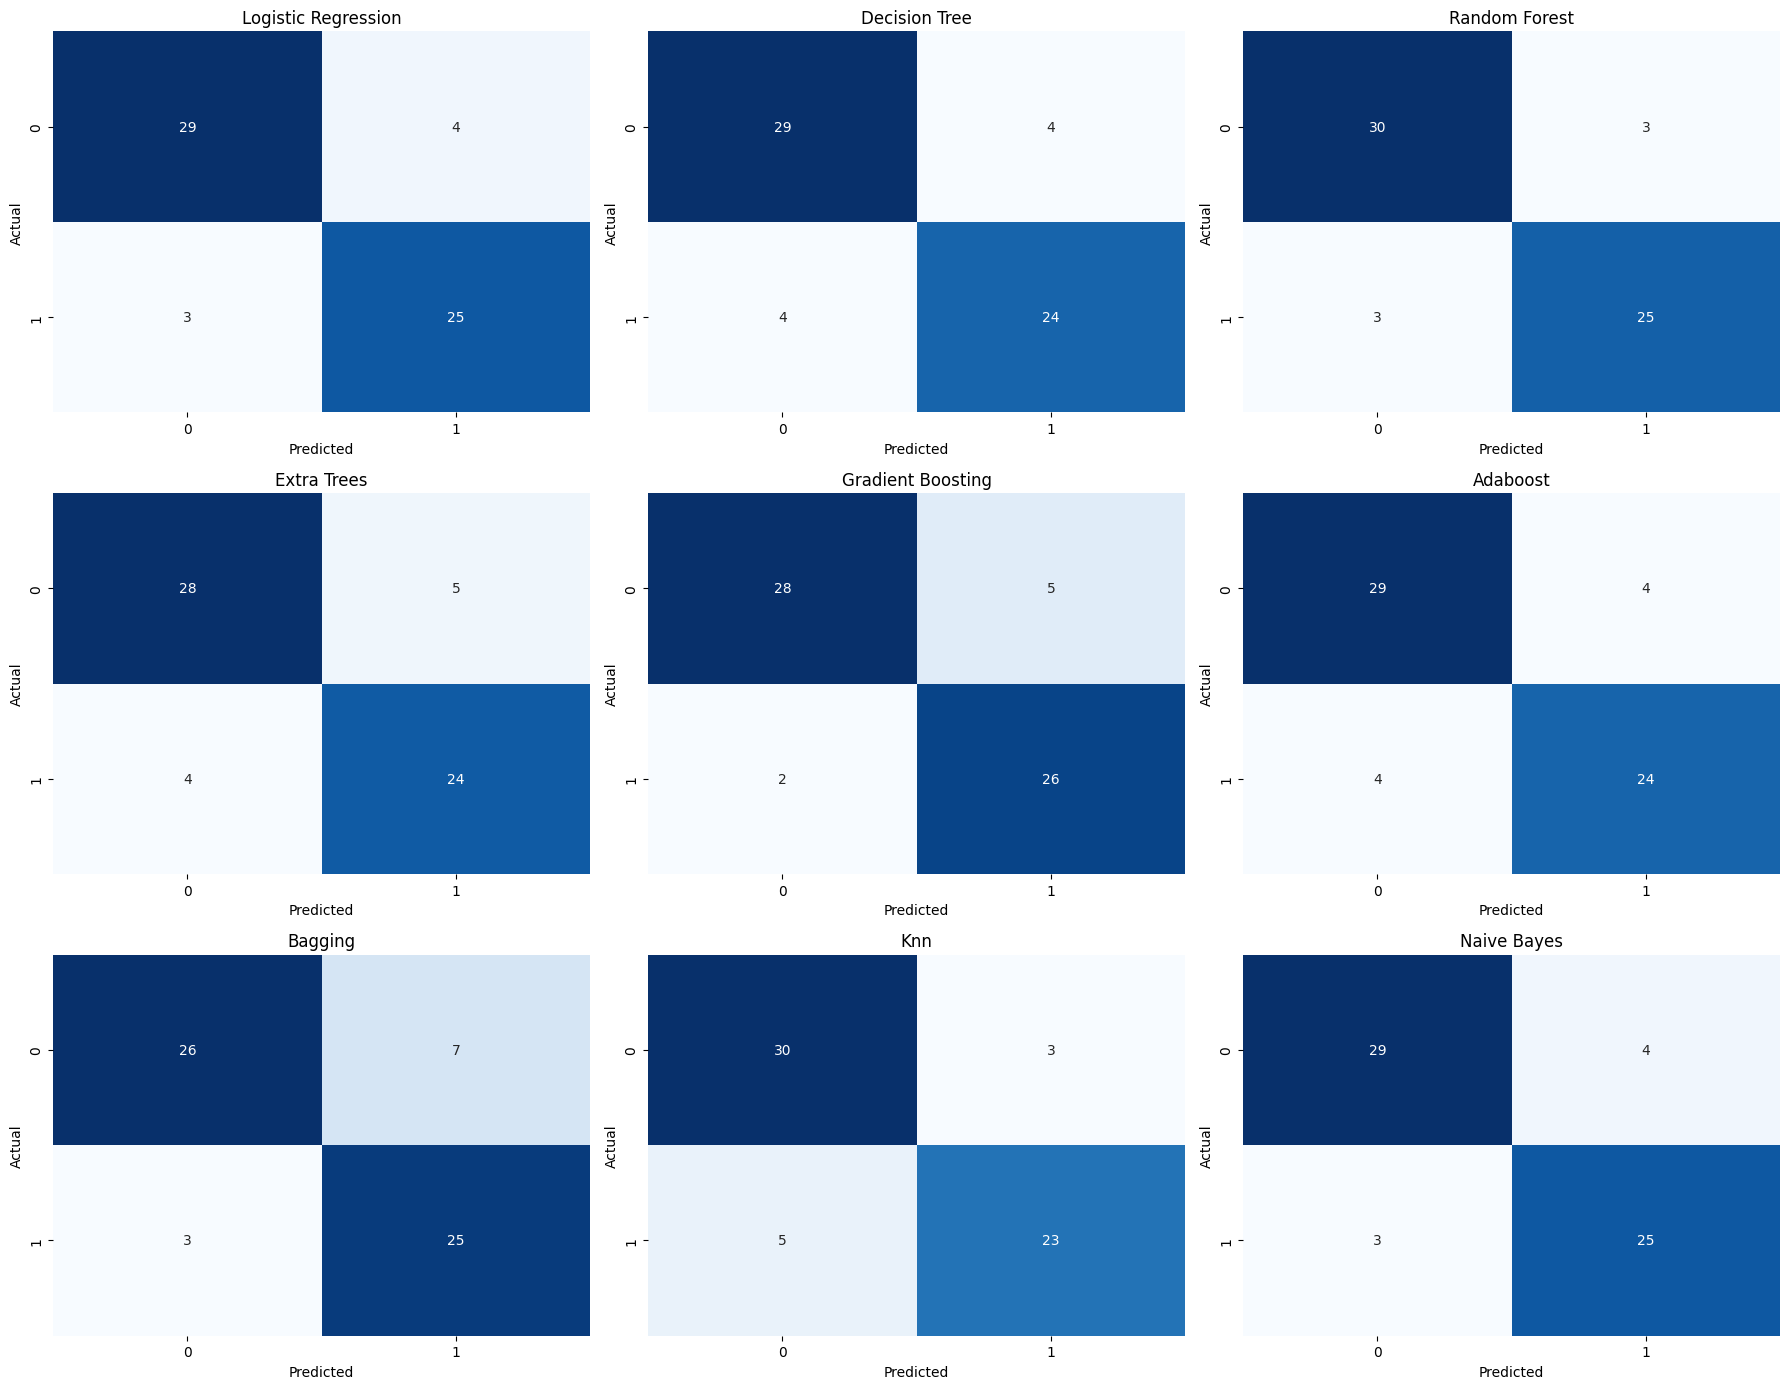

In [22]:
plt.figure(figsize=(18, 14))

for i, (name, model) in enumerate(models.items(), 1):
    plt.subplot(3, 3, i)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False
    )

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()


## Plot ROC Curves

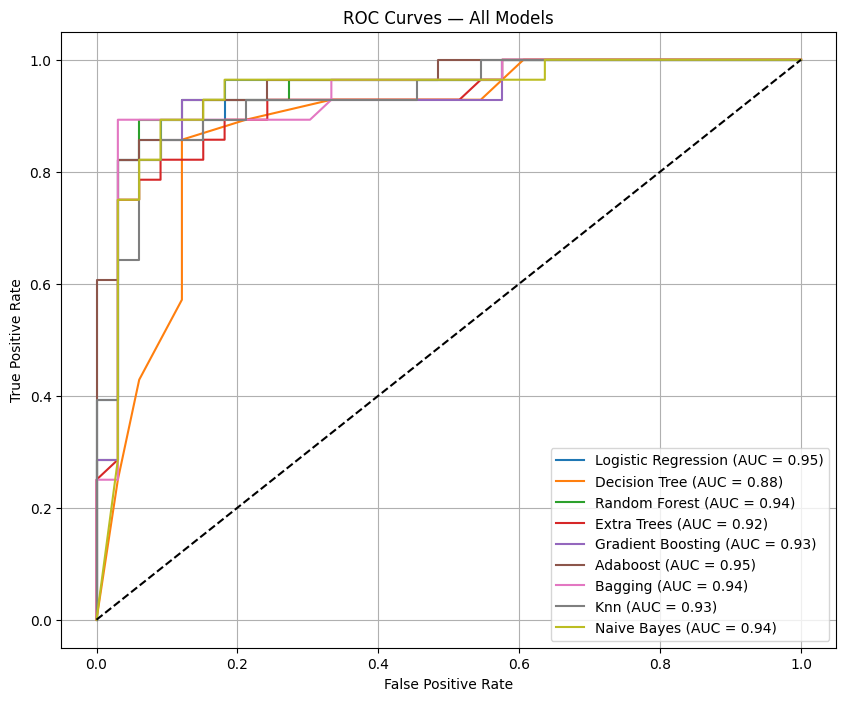

In [23]:
plt.figure(figsize=(10, 8))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
plt.grid(True)
plt.show()


## Calculate ROC-AUC Scores

In [24]:
roc_scores = {}

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    roc_scores[name] = auc(*roc_curve(y_test, y_prob)[:2])

pd.DataFrame.from_dict(
    roc_scores,
    orient="index",
    columns=["ROC-AUC"]
).sort_values("ROC-AUC", ascending=False)


,ROC-AUC
Adaboost,0.954545
Logistic Regression,0.948052
Random Forest,0.944805
Bagging,0.936688
Naive Bayes,0.936147
Gradient Boosting,0.930736
Knn,0.929654
Extra Trees,0.919913
Decision Tree,0.883658


## Final Model Comparison Leaderboard

In [25]:
final_results = results_df.copy()
final_results["ROC-AUC"] = final_results.index.map(roc_scores)

final_results.sort_values(
    by=["F1-score", "ROC-AUC"],
    ascending=False
)


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Random Forest,0.901639,0.892857,0.892857,0.892857,0.944805
Gradient Boosting,0.885246,0.838710,0.928571,0.881356,0.930736
Logistic Regression,0.885246,0.862069,0.892857,0.877193,0.948052
Naive Bayes,0.885246,0.862069,0.892857,0.877193,0.936147
Adaboost,0.868852,0.857143,0.857143,0.857143,0.954545
Decision Tree,0.868852,0.857143,0.857143,0.857143,0.883658
Knn,0.868852,0.884615,0.821429,0.851852,0.929654
Extra Trees,0.852459,0.827586,0.857143,0.842105,0.919913
Bagging,0.836066,0.781250,0.892857,0.833333,0.936688
